In [ ]:
from rl_opts.virtual_abm import virtual_ABM

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from tqdm.notebook import tqdm
import scipy.constants as const

import os
import pickle
import time

from rl_opts.virtual_abm import get_ABM_motion


from ipywidgets.widgets import Dropdown, IntSlider
from ipywidgets import interact

### Auxilliary Functions

In [ ]:
## Data storing dictionary
class DataStore(object):
    def __init__(self, write_flag = True, chkpt_dir = 'tmp/data/'):
        self.trajectories = dict()
        self.displacements = dict()
        self.trajectories_1 = dict()
        self.target = dict()
        self.action_phase_data = dict()
        self.reward_value = dict()
        self.epi_lengths = dict()
        self.matrix = dict()
        self.epi_key = str()

        self.chkpt_check(write_flag, chkpt_dir)

    def chkpt_check(self, write_flag, chkpt_dir):
        if not os.path.exists(chkpt_dir) and write_flag:
            os.makedirs(chkpt_dir)
        self.chkpoint_dir = chkpt_dir
    
    def append_dict(self, episode):
        # for i in range(self.n):
        self.epi_key = str('epi_') + str(episode)
        self.trajectories[self.epi_key] = []
        self.displacements[self.epi_key] = []
        self.trajectories_1[self.epi_key] = []
        self.target[self.epi_key] = []
        self.action_phase_data[self.epi_key] = []
        self.reward_value[self.epi_key] = []
        self.epi_lengths[self.epi_key] = []
        self.matrix[self.epi_key] = []
    
    def save_trajectory(self, position, disp, raw_pos):
        self.trajectories[self.epi_key].append(position)
        self.displacements[self.epi_key].append(disp)
        self.trajectories_1[self.epi_key].append(raw_pos)
    
    def save_target(self, target):
        self.target[self.epi_key].append(target)
    
    def save_action_phase(self, action, phase):
        self.action_phase_data[self.epi_key].append(np.array([action, phase]))
    
    def save_reward(self, r):
        self.reward_value[self.epi_key].append(r)
    
    def save_length(self, L):
        self.epi_lengths[self.epi_key].append(L)

    def save_h_matrix(self, h_matrix):
        self.matrix[self.epi_key].append(h_matrix)
    
    def save_dict(self, name):
        data = self.__dict__
        chkpoint_file = os.path.join(self.chkpoint_dir , str(name) + '_rl_opts.pkl')
        with open(chkpoint_file, 'wb') as f:
            pickle.dump(data, f)
    
    def open_dict(self, name):
        # Load Data
        datafile = str(name) + '_rl_opts.pkl'
        data_path = os.path.join(self.chkpoint_dir, datafile)
        with open(data_path, 'rb') as file:
            load_data = pickle.load(file)
        return load_data
    

def generate_targets(L, Nt, t):
    '''
    Function for generating lattice target
    '''
    
    num_cells = np.sqrt(Nt)
    unit_cell_size = L/num_cells

    # Generate grid of cell indices
    cell_x, cell_y = np.meshgrid(np.arange(num_cells), np.arange(num_cells))

    # Flatten the grids and scale to unit cell size
    cell_x = cell_x.flatten() * unit_cell_size + unit_cell_size/2
    cell_y = cell_y.flatten() * unit_cell_size + unit_cell_size/2

    # Generate random offsets within each cell
    offset_x = np.random.uniform(-unit_cell_size/2, unit_cell_size/2)*int(t != 0)
    offset_y = np.random.uniform(-unit_cell_size/2, unit_cell_size/2)*int(t != 0)

    # Final point coordinates
    x = (cell_x + offset_x)%L
    y = (cell_y + offset_y)%L

    # Combine into a single array of coordinates
    points = np.column_stack((x, y))
    return points

def large_grid(L, n_cells, n_targets, t=0):
    '''
    Function for generating clustered lattice targets
    '''

    unit_cell_size = L / n_cells

    # large checkerboard
    checker = (np.arange(n_cells)[:, None] + np.arange(n_cells)) % 2
    Nt_grid = np.where(checker == 0, n_targets[0], n_targets[1])

    all_points = []

    for i in range(n_cells):
        for j in range(n_cells):

            Nt = int(Nt_grid[i, j])

            # generate local targets inside one large cell
            pts = generate_targets(unit_cell_size, Nt,t)

            # shift to global position
            pts[:, 0] += i * unit_cell_size
            pts[:, 1] += j * unit_cell_size

            all_points.extend(pts.tolist())
    all_points = np.array(all_points)

    return all_points

# def large_grid(L, n_cells, n_targets, t=0):

#     unit_cell_size = L / n_cells

#     checker = (np.arange(n_cells)[:, None] + np.arange(n_cells)) % 2
#     Nt_grid = np.where(checker == 0, n_targets[0], n_targets[1])

#     gx, gy = np.meshgrid(
#         np.arange(n_cells)*unit_cell_size,
#         np.arange(n_cells)*unit_cell_size,
#         indexing="ij"
#     )

#     gx = gx.ravel()
#     gy = gy.ravel()
#     Nt_flat = Nt_grid.ravel()

#     all_pts = []

#     for Nt in np.unique(Nt_flat):

#         mask = Nt_flat == Nt
#         n_masked = int(np.sum(mask))
#         offsets = np.column_stack((gx[mask], gy[mask]))  # (n_masked, 2)

#         # Base lattice without random offset
#         base = generate_targets(unit_cell_size, int(Nt), 0)  # (Nt, 2)

#         if t != 0:
#             # Independent per-cell random shifts, wrapped within unit cell
#             cell_shifts = np.random.uniform(0, unit_cell_size, (n_masked, 1, 2))
#             shifted = (base[None, :, :] + cell_shifts) % unit_cell_size  # (n_masked, Nt, 2)
#         else:
#             shifted = np.broadcast_to(base[None, :, :], (n_masked, int(Nt), 2))

#         pts = (shifted + offsets[:, None, :]).reshape(-1, 2)
#         all_pts.append(pts)

#     return np.vstack(all_pts)

def check_terminal(L, xy):
    '''
    Check whether the agent has reached terminal state or not
    '''
    threshold = 0.02
    # encounter = self.check_encounter()
    # (any(xy>=self.L*(1-threshold)) or any(xy<=self.L*threshold)) or
    if (any(xy>=L*(1-threshold)) or any(xy<=L*threshold)):
        done = True
    else:
        done = False
    # elif encounter == 1:
    #     self.done = True
    return done

def load_save_h_matrix(episode, mode = 'Save', chkpt_dir = 'tmp/h_matrix/'):
    '''
    Function forr loading and saving matrix
    '''
    global wrap, data_dict

    if not os.path.exists(chkpt_dir):
        os.makedirs(chkpt_dir)

    filename = 'h_matrix_' + str(episode) + '.txt'
    path = os.path.join(chkpt_dir, filename)

    if mode =='Save':
        h_matrix = data_dict.matrix['epi_' + str(episode)][0]
        np.savetxt(path, h_matrix)
        return ('H-matrix Saved')
    
    elif mode =='Load':
        h_matrix = np.loadtxt(path)
        wrap.agent.h_matrix = h_matrix
        return ('H-matrix Loaded')


### Init Functions

In [ ]:
def init(L, r, N_eps, time_ep, n_cells, n_targets, gamma = 1e-8, eta = 1e-2):
    global wrap, data_dict
    global done, epoch
    global num_cells, num_targets

    ### Get target numbers
    num_cells = n_cells
    num_targets = n_targets
    targets = large_grid(L, num_cells, num_targets, t = 0)

    ### Initiation of RL parameters
    wrap = virtual_ABM(L = L, r = r,
                   num_episodes = N_eps,
                   time_ep = time_ep,
                   gamma_damping = gamma, # This is the learning parameter gamma from PS
                   eta_glow_damping = eta, # This is the learning parameter eta from PS
                   Nt = targets.shape[0]
                  )
    
    # pBP =  1e-2  # initial probability of changing when passive
    # pABP =  1e-4 # initial probability of changing when active
    
    pBP = 5e-1  # initial probability of changing when passive
    pABP =  5e-1 # initial probability of changing when active

    wrap.agent.h_matrix[1, ::2] = pBP / (1-pBP)
    wrap.agent.h_matrix[1, 1::2] = pABP / (1-pABP)
    
    # We first initialize the environmnet. This initializes the epoch counter, sets the
    # the particle and agent in random positions and resents resetting some of the learning parameters
    wrap.init_training()

    # Initial phase of the agent. Note that the agent always starts in the passive phase. 
    # phi =  wrap.current_phase
    # If you want to start in the active phase, you just need to set:
    wrap.current_phase = 0

    #Initiating the epoch as a dummy variable
    epoch = wrap.epoch

    # Memory allocation of saving data
    # particle_pos = np.zeros((wrap.num_episodes, wrap.time_ep, 2))
    # target_pos = np.zeros((wrap.num_episodes, wrap.time_ep, 2))
    # phases = np.zeros((wrap.num_episodes, wrap.time_ep))
    # rewards = np.zeros((wrap.num_episodes, wrap.time_ep))
    data_dict = DataStore()
    return ('Module Initialized')



In [ ]:
scale = 1/100
D = 1*(const.Boltzmann*300/(6*const.pi*1e-3*1.1e-6))*1e12 # Diffusion coefficient (mum² s⁻¹)
L = 75 # Size of the box (mu) 
tau = L**2 / (4*D) #  Typical time required by a passive particle to cover this distance (s)

Pe = 100 # Péclet number
# v = Pe * L / tau  # self-propulsion velocity
v = 2.5
dt = 0.2 # Integration time
vdt = v*dt 
ell = 1 # Dimensionless persistence length
D_theta = (const.Boltzmann*300/(8*const.pi*1e-3*(1.1e-6)**3))  # Rotational diffusion coefficient

sigma = np.sqrt(2*D*dt); # sigma for translational
sigma_theta = np.sqrt(2*D_theta*dt) # sigma for rotational

r = 1 # Size of the target

N_eps = 2000
time_ep = 2000

# N_targets = 100
n_cells = 3
n_targets = [16, 1]

gamma = 1e-4
eta = 0.1
init(L, r, N_eps, time_ep, n_cells, n_targets, gamma = gamma, eta=eta)

'Module Initialized'

### Run Function

In [ ]:
def run_episode(first_call, x, y, learn = True):
    global wrap, data_dict
    global done, epoch, phi, action, reward, displacement
    global old_position, new_position
    global num_cells, num_targets, target_positions

    # for first_call True
    if first_call == 1:
        # wrap.env.Nt = N_targets

        # First observation
        wrap.env.positions[0] = np.array([x, y])
        old_position = wrap.env.positions[0].copy()

        # start in passive phase
        wrap.current_phase = 0
        phi =  wrap.current_phase
        action = 0
        reward = 0
        displacement = (0,0)

        # set done to false
        done = False
        wrap.done = False
        data_dict.append_dict(wrap.epoch)

    else:

        new_position = [x, y]
        # old_position = wrap.env.positions[0].copy()

        # Now we send this to the wrapper. The step function can also give you the reward if asked:
        displacement = (new_position[0]-old_position[0], new_position[1]-old_position[1])
        action, reward = wrap.step(displacement, return_reward=True, learn=learn)
        old_position = new_position.copy()

        # And let's save the rewards (nothing different than zero to be expected here)
        # rewards[wrap.epoch-1, wrap.t_ep-1] = reward # minus ones are needed here because wrap.step already updated the epoch and t_ep
        done = wrap.done

    if reward == 1 or first_call == 1:
        # wrap.env.target_positions = generate_targets(wrap.env.L, wrap.env.Nt, wrap.t_ep)
        target_positions = large_grid(wrap.env.L, num_cells, num_targets, t = wrap.t_ep)
        wrap.env.target_positions = target_positions.copy()
    # else:
    #     wrap.env.target_positions = target_positions
    
    ## Saving stuff
    data_dict.save_trajectory(wrap.env.positions[0].copy(), np.array(displacement), np.array([x,y]))
    data_dict.save_target(wrap.env.target_positions.copy())
    
    data_dict.save_reward(reward)
    
    bc_done = check_terminal(wrap.env.L, wrap.env.positions[0])

    phi = wrap.current_phase
    epoch = wrap.epoch
    steps = wrap.t_ep

    data_dict.save_action_phase(action, phi)

    if done or bc_done:
        episode_done = True
        data_dict.save_length(steps)
        data_dict.save_h_matrix(wrap.agent.h_matrix)
    else:
        episode_done = False

    # target_position = wrap.env.target_positions[0]
    
    return int(phi), reward, episode_done, target_positions, steps, epoch

### Run

In [ ]:
### Save H-Matrix
# load_save_h_matrix(1300, mode='Load')

In [ ]:
# x,y = (np.random.rand(1, 2)*L)[0]
# x0, y0 = wrap.env.positions[0].copy()
theta = 2*np.pi*np.random.rand() 
done = False
for i in tqdm(range(N_eps)):
    x,y = (np.random.rand(1, 2)*L/2 + L/4)[0]
    done = False
    first_call = int(True)
    phi = wrap.current_phase
    while not done:
        x1, y1, theta = get_ABM_motion(x, y, theta, phi, vdt, sigma, sigma_theta, L, bc_periodic=False)
        # print(wrap.done)
        phi, reward, done, target_position, steps, epoch = run_episode(first_call, x1, y1, learn= True)
        first_call = int(False)
        # print(i, done, wrap.epoch)
        # Update the phase for the ABM generator. This should be the input in the experiment to change phase too.
        # if action == 1:
        #     phi = 1 - phi
        x, y = x1, y1
    if done:
        # Manually initiate the epoch when done
        wrap.init_epoch()

  0%|          | 0/2000 [00:00<?, ?it/s]

In [ ]:
traj = np.array(data_dict.trajectories['epi_1000'])
traj_1 = np.array(data_dict.trajectories_1['epi_1000'])
disp = np.array(data_dict.displacements['epi_1000'])
wrap.env.positions

array([[45.01284972, 56.97253199]])

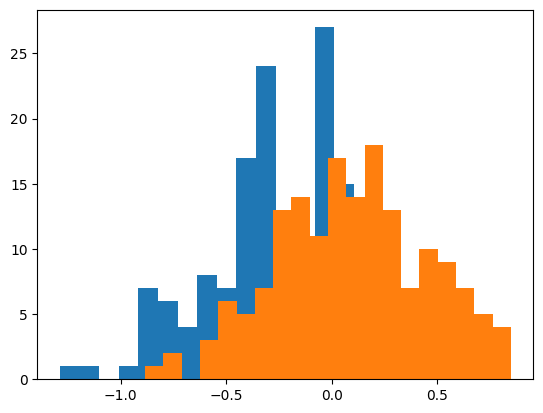

In [ ]:
plt.hist(disp[:,0], 20)
plt.hist(disp[:,1], 20)
plt.show()

(np.float64(-0.5503733358528862),
 np.float64(39.31068485059041),
 np.float64(39.31923602906736),
 np.float64(79.18029421551066))

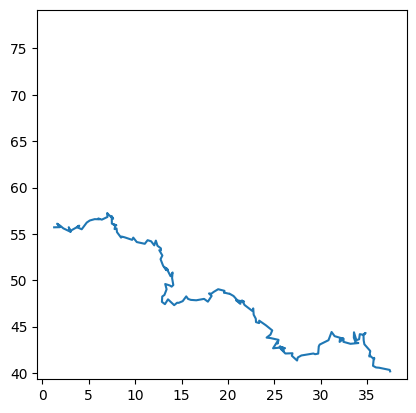

In [ ]:
plt.plot(traj[:,0], traj[:,1])
# plt.plot(traj_1[:,0], traj_1[:,1])
plt.setp(plt.gca(), xlim=(0, L), ylim=(0, L))
plt.axis('square')

### Evaluation and plot

Text(0, 0.5, 'Episode Length')

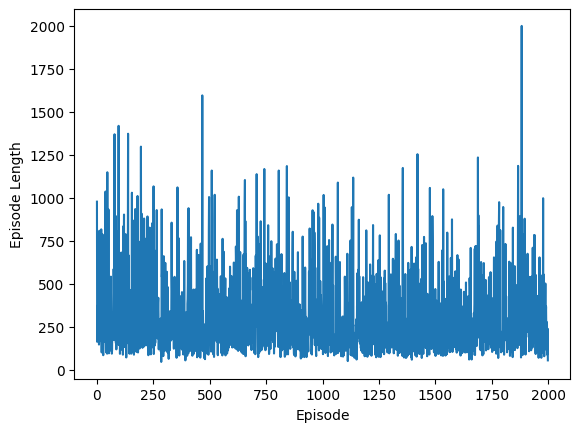

In [ ]:
epi_len = []
for i in range(N_eps):
    epi_len.append(data_dict.epi_lengths['epi_'+str(i)][0])

epi_len = np.array(epi_len)
plt.plot(epi_len)
plt.xlabel('Episode')
plt.ylabel('Episode Length')

In [ ]:
def plot_ep(ep, step):


    key = 'epi_' + str(ep)
    actions=np.array(data_dict.action_phase_data[key])[:,0]
    phases=np.array(data_dict.action_phase_data[key])[:,1]
    epi_len = data_dict.epi_lengths[key][0]

    plt.figure(figsize=(17,3))
    plt.subplot2grid((1, 4), (0, 0))
    # plt.plot()
    # x, y  = particle_pos[ep,step,0], particle_pos[ep,step,1]
    traj= np.array(data_dict.trajectories[key])
    target_positions = data_dict.target[key][step]
    plt.plot(traj[step,0], traj[step, 1], 'ko')
    plt.plot(traj[:step,0], traj[:step, 1], 'k-', alpha= 0.5, lw = 1)
    plt.title(f"{x:.4f},{y:.4f}, phase = {phases[step]}")
    # for k1 in range(particle_pos[ep].shape[0]):
    #     plt.plot(xv1[k1:k1+2], yv1[k1:k1+2], color=colors1[k1], alpha = 0.6, lw = 1.5)

    
    # for i in range(len(data_dict.target[key][step])):
    #     circle = patches.Circle((data_dict.target[key][step][i,0],data_dict.target[key][step][i,1]), radius=r, facecolor='C1') ###
    #     plt.gca().add_patch(circle)
    N_targets = target_position.shape[0]
    for i in range(N_targets):
        circle = patches.Circle((target_positions[i,0],target_positions[i,1]), radius=r, facecolor='C1') ###
        plt.gca().add_patch(circle)
    
    reward_val = data_dict.reward_value[key]

    plt.axis('square')
    plt.setp(plt.gca(), xlim = (0, L), ylim = (0, L), xlabel = fr'$L = {L} \ \mu m$', aspect = 'equal');
    plt.setp(plt.gca(), ylabel = fr'$L = {L} \ \mu m$')
    
    plt.subplot2grid((1, 4), (0, 1), colspan=3)
    # plt.plot(np.arange(epi_len), phases[:-1], zorder = 10)
    plt.plot(reward_val, zorder = 10, label = 'r')
    plt.plot(phases, zorder = 10, label = '$\\phi$')
    # plt.plot(actions, zorder = 10, label = 'a')
    plt.gca().set_title(f'Episode {ep}')
    plt.axhline(0, c = 'k', ls = '--', alpha = 0.3)
    plt.axhline(1, c = 'k', ls = '--', alpha = 0.3)
    plt.axvline(step, c = 'b', ls = '--')
    plt.setp(plt.gca(), xlabel = 'time', yticks = [0,1], yticklabels = [], xlim = (0, 200))
    plt.legend()
    print(np.argwhere(np.array(reward_val)==1).T)

    sl_step.max = epi_len -1
    # plt.setp(plt.gca(), yticklabels = ['passive', 'active']);

sl_step = IntSlider(min=0, max = time_ep-1, step = 1)
interact(plot_ep, ep =IntSlider(min=0, max = N_eps-1, step = 1, value = 1000),
                step = sl_step)

interactive(children=(IntSlider(value=1000, description='ep', max=1999), IntSlider(value=0, description='step'…

<function __main__.plot_ep(ep, step)>

In [ ]:
reward_val = []
mean_rewards = []
for i in range(N_eps):
    epi_key = 'epi_' + str(i)
    reward_val.append(np.array(data_dict.reward_value[epi_key]))
    mean_rewards.append(np.mean(reward_val[-1]))

mean_rewards = np.array(mean_rewards)

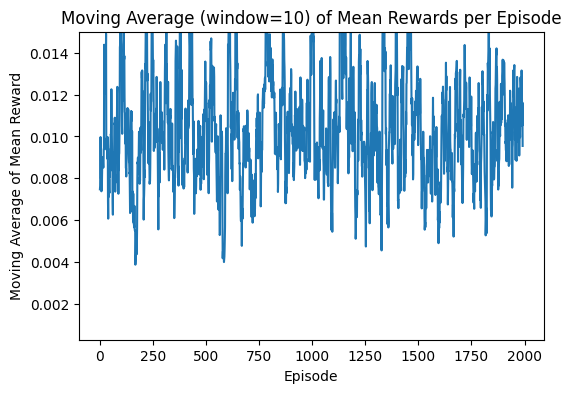

In [ ]:
window = 10  # moving average window size
# mean_rewards = reward_val.mean(axis=1)
moving_avg = np.convolve(mean_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(moving_avg)+1)[:], moving_avg[:])
plt.ylim(0, 0.015)
plt.xlabel('Episode')
plt.ylabel('Moving Average of Mean Reward')
plt.title(f'Moving Average (window={window}) of Mean Rewards per Episode')
plt.ylim(0.3e-3, 1.5e-2)
plt.show()

In [ ]:
### Velocity
vel_mag_pasv = []
vel_mag_actv = []
phase_frac = []
for i in range(0, N_eps):
    key = 'epi_' + str(i)
    traj = np.array(data_dict.trajectories[key])
    velocities = np.diff(traj, axis = 0)

    phases = np.array(data_dict.action_phase_data[key])[:-1,1]
    pasv_phase_arg = np.argwhere(phases==0).squeeze()
    actv_phase_arg = np.argwhere(phases==1).squeeze()
    actv_phase_fraction = (phases.sum()/phases.shape[0])
    pasv_phase_fraction = 1 - (phases.sum()/phases.shape[0])
    # phase_frac.append([pasv_phase_arg.shape[0]/phases.shape[0], 
    #                    actv_phase_arg.shape[0]/phases.shape[0]])
    phase_frac.append([pasv_phase_fraction, 
                       actv_phase_fraction])
    if pasv_phase_arg.tolist():
        velocities_pasv_mag = np.linalg.norm(velocities[pasv_phase_arg], axis = 1).tolist()
    if actv_phase_arg.tolist():
        velocities_actv_mag = np.linalg.norm(velocities[actv_phase_arg], axis = 1).tolist()

    vel_mag_pasv.extend(velocities_pasv_mag)
    vel_mag_actv.extend(velocities_actv_mag)

vel_mag_pasv = np.array(vel_mag_pasv)/dt
vel_mag_actv = np.array(vel_mag_actv)/dt

phase_frac = np.array(phase_frac)

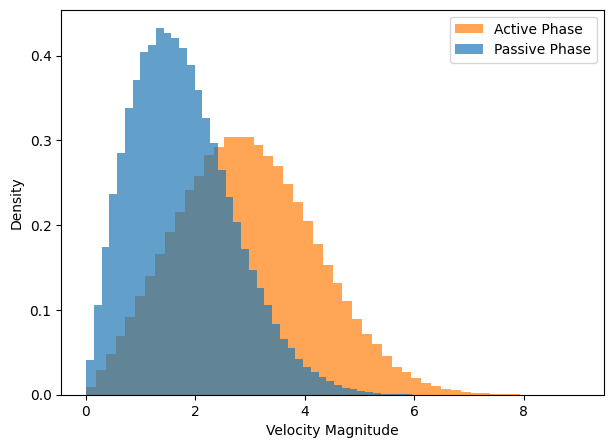

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(vel_mag_actv, bins=50, alpha=0.7, label='Active Phase', color='C1', density=True)
plt.hist(vel_mag_pasv, bins=50, alpha=0.7, label='Passive Phase', color='C0', density=True)
plt.setp(plt.gca(), xlabel = 'Velocity Magnitude', ylabel = 'Density')
plt.legend()
plt.show()

<matplotlib.legend.Legend>

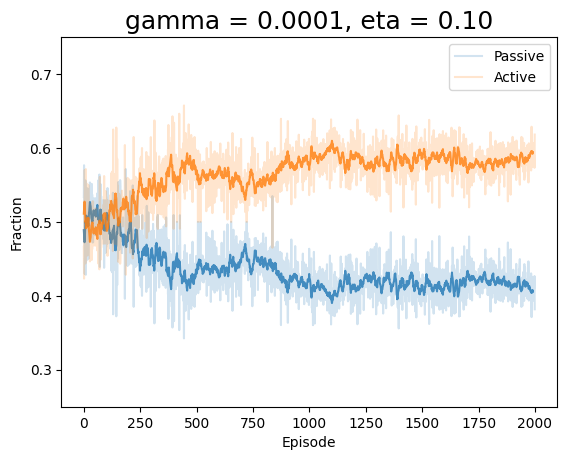

In [ ]:
def moving_avg(data, window = 10):
    window = window  # moving average window size
    moving_avg = np.convolve(data, np.ones(window)/window, mode='valid')
    return moving_avg

plt.plot(phase_frac[:,0], label = 'Passive', alpha = 0.2)
plt.plot(moving_avg(phase_frac[:,0]), c = 'C0', alpha = 0.8)

plt.plot(phase_frac[:,1], label = 'Active', alpha = 0.2)
plt.plot(moving_avg(phase_frac[:,1]), c = 'C1', alpha = 0.8)
plt.xlabel('Episode')
plt.ylabel('Fraction')
plt.ylim(0.25,0.75)
plt.title (f'gamma = {gamma}, eta = {eta:.2f}', fontdict={'fontsize':18})
plt.legend()

Text(0.5, 1.0, 'gamma = 0.0001, eta = 0.10')

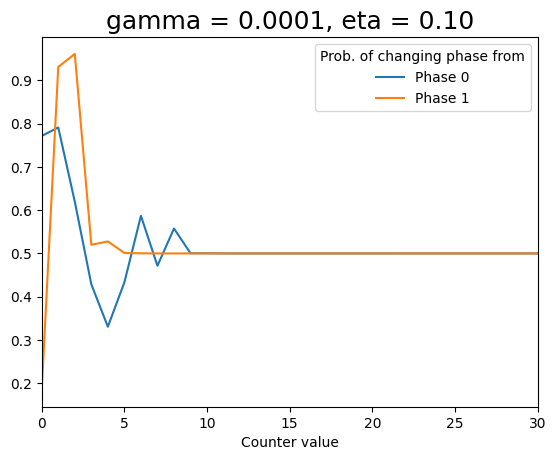

In [ ]:
# Now we get the probability of each action by normalizing the h_matrix
probs = wrap.agent.h_matrix / wrap.agent.h_matrix.sum(axis=0)

prob_change_phase0 = probs[1, ::2]
prob_change_phase1 = probs[1, 1::2]

# These two objects must have same length
assert prob_change_phase0.shape == prob_change_phase1.shape


# And now we can e.g. plot them as a function of the counter

plt.plot(np.arange(500), prob_change_phase0, label = 'Phase 0')
plt.plot(np.arange(500), prob_change_phase1, label = 'Phase 1')
plt.setp(plt.gca(), xlim=(0,30))
plt.legend(title = 'Prob. of changing phase from')
plt.xlabel('Counter value')
plt.title (f'gamma = {gamma}, eta = {eta:.2f}', fontdict={'fontsize':18})

In [ ]:
a

NameError: name 'a' is not defined

In [ ]:
os.makedirs('./grid_cluster/', exist_ok=True)
# np.savetxt('./grid_cluster/grid_cluster_h_matrix_5.txt', wrap.agent.h_matrix,)
# np.savetxt('./grid_cluster/grid_cluster_phase_frac_5.txt', phase_frac,)
data_dict.chkpoint_dir='./grid_cluster/'
data_dict.save_dict('grid_cluster_data_5')

In [ ]:
a

#### Extract Episode GIF

In [ ]:
from IPython.display import Video

import matplotlib.animation as animation

# Extract episode data
ep = 1022
key = 'epi_' + str(ep)
traj = np.array(data_dict.trajectories[key])
actions = np.array(data_dict.action_phase_data[key])[:, 0]
phases = np.array(data_dict.action_phase_data[key])[:, 1]
epi_len = data_dict.epi_lengths[key][0]
reward_val = data_dict.reward_value[key]

# Create figure and subplots
fig = plt.figure(figsize=(17, 3))
ax1 = plt.subplot2grid((1, 4), (0, 0))
ax2 = plt.subplot2grid((1, 4), (0, 1), colspan=3)

def animate(step):
    ax1.clear()
    ax2.clear()
    
    # Left plot: trajectory and targets
    target_positions = data_dict.target[key][step]
    ax1.plot(traj[step, 0], traj[step, 1], 'ko')
    ax1.plot(traj[:step, 0], traj[:step, 1], 'k-', alpha=0.5, lw=1)
    ax1.set_title(f"{traj[step,0]:.4f},{traj[step,1]:.4f}, phase = {phases[step]}")
    
    for i in range(target_positions.shape[0]):
        circle = patches.Circle((target_positions[i, 0], target_positions[i, 1]), radius=r, facecolor='C1')
        ax1.add_patch(circle)
    
    ax1.set_xlim(0, L)
    ax1.set_ylim(0, L)
    ax1.set_aspect('equal')
    # ax1.set_xlabel(f'$L = {L} \\mu m$')
    # ax1.set_ylabel(f'$L = {L} \mu m$')
    
    # Right plot: rewards and phases
    ax2.plot(reward_val, zorder=10, label='r')
    ax2.plot(phases, zorder=10, label='$\\phi$')
    ax2.axhline(0, c='k', ls='--', alpha=0.3)
    ax2.axhline(1, c='k', ls='--', alpha=0.3)
    ax2.axvline(step, c='b', ls='--')
    ax2.set_title(f'Episode {ep}')
    ax2.set_xlabel('time')
    ax2.set_xlim(0, min(200, epi_len))
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_yticks([0, 1])
    ax2.legend()

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=epi_len-1, interval=50, repeat=True)

# Save as mp4
# anim.save('episode_962.mp4', writer='ffmpeg', dpi=100)
anim.save('epi_1022.gif', writer='PillowWriter', fps=50)
plt.close()

### Grid Search

In [ ]:
N_targets, L, r, v

In [ ]:
def train_loop_abm(gamma, eta, N_eps):
    init(L, r, N_eps, time_ep, N_targets, gamma = gamma, eta = eta)
    # rewards = np.zeros((N_eps, wrap.time_ep))

    epi_rewards_mean = []
    pasv_phase_frac = []
    for _ in range(N_eps):
        x,y = (np.random.rand(1, 2)*L/2 + L/4)[0]
        theta = 2*np.pi*np.random.rand()
        
        done = False
        first_call = int(True)
        phi = wrap.current_phase

        epi_rewards= []
        epi_phases = []
        while not done:
            x1, y1, theta = get_ABM_motion(x, y, theta, phi, vdt, sigma, sigma_theta, L, bc_periodic=False)
            phi, reward, done, _, _, _ = run_episode(first_call, x1, y1)
            first_call = int(False)

            x, y = x1, y1
            epi_rewards.append(reward)
            epi_phases.append(phi)
            if done:
                # Manually initiate the epoch when done
                wrap.init_epoch()
        epi_rewards_mean.append(np.array(epi_rewards).mean())
        epi_phases = np.array(epi_phases)
        pasv_phase_sum_frac = 1 - (epi_phases.sum()/epi_phases.shape[0])
        pasv_phase_frac.append(pasv_phase_sum_frac)
    
    return np.array(epi_rewards_mean), np.array(pasv_phase_frac)

In [ ]:
gammas = np.logspace(-7,-1,10)
etas = np.logspace(-3,-0,10)

N_episodes = int(1.5e3)


rewards = np.zeros((gammas.shape[0], etas.shape[0], N_episodes))
pasv_fraction = np.zeros((gammas.shape[0], etas.shape[0], N_episodes))
for idxg, gamma in tqdm(enumerate(gammas)):
    for idxe, eta in enumerate(etas):
        rews, pasv_frac = train_loop_abm(gamma, eta, N_episodes)

        rewards[idxg, idxe] = rews
        pasv_fraction[idxg, idxe] = pasv_frac    

In [ ]:
plt.matshow(rewards[:,:,-500:].mean(-1))

plt.xlabel('eta')
plt.ylabel('gamma')
plt.xticks(ticks=np.arange(len(etas)), labels=[f"{e:.2g}" for e in etas], rotation=45)
plt.yticks(ticks=np.arange(len(gammas)), labels=[f"{g:.1g}" for g in gammas])
plt.colorbar(label ='Average reward over last 500 episodes')

In [ ]:
plt.matshow(pasv_fraction[:,:,-300:].mean(-1), cmap = 'bwr', vmin = 0, vmax = 1)

plt.xlabel('eta')
plt.ylabel('gamma')
plt.xticks(ticks=np.arange(len(etas)), labels=[f"{e:.2g}" for e in etas], rotation=45)
plt.yticks(ticks=np.arange(len(gammas)), labels=[f"{g:.1g}" for g in gammas])
plt.colorbar(label ='Average Passive Fraction of last 400 episodes')

#### Saving Stuff

In [ ]:
params = np.vstack([etas, gammas])
np.savetxt('./test_parameter_values/params_eta_gamma_grid_L=100_N=100_v=3_r=1.txt', params)

In [ ]:
reward_mean = rewards[:,:,-500:].mean(-1)
mean_pasv_frac = pasv_fraction[:,:,-300:].mean(-1)

np.savetxt('./test_parameter_values/mean_reward_grid_L=100_N=100_v=5_r=1.txt', reward_mean)
np.savetxt('./test_parameter_values/mean_pasv_frac_grid_L=100_N=100_v=5_r=1.txt', mean_pasv_frac)

### Calculate MSD

In [ ]:
def autocorrFFT(x):
    N = len(x)
    F = np.fft.fft(x, n=2*N)  #2*N because of zero-padding
    PSD = F * F.conjugate() # power spectrum density
    res = np.fft.ifft(PSD)
    res = (res[:N]).real #now we have the autocorrelation in convention B
    n = N * np.ones(N) - np.arange(0,N) #divide res(m) by (N-m)
    return res / n #this is the autocorrelation in convention A

def msd_fft(r):
    N = len(r)
    D = np.square(r).sum(axis=1) 
    D = np.append(D, 0) 
    S2 = sum([autocorrFFT(r[:, i]) for i in range(r.shape[1])])
    Q = 2 * D.sum()
    S1 = np.zeros(N)
    for m in range(N):
        Q = Q - D[m - 1] - D[N - m]
        S1[m] = Q / (N - m)
    return S1 - 2 * S2

In [ ]:
def compute_msd_from_traj(r, dt=dt, unit_scale=1.0):
    """
    Compute MSD from a single trajectory array r (N,2) using msd_fft defined in the notebook.
    Returns time lags (seconds) and MSD (units^2 scaled by unit_scale**2).
    """
    r = np.asarray(r)
    msd = msd_fft(r) * (unit_scale**2)
    t = np.arange(len(msd)) * dt
    return t, msd

def msd_for_episode(ep, use_raw=False, unit_scale=1.0):
    """
    Compute MSD for one episode index or key.
    ep: int (episode number) or string key 'epi_#'
    use_raw: if True use trajectories_1 instead of trajectories
    """
    key = f'epi_{int(ep)}' if not isinstance(ep, str) else ep
    traj = np.array(data_dict.trajectories_1[key]) if use_raw else np.array(data_dict.trajectories[key])
    return compute_msd_from_traj(traj, dt=dt, unit_scale=unit_scale)

In [ ]:
t, msd = msd_for_episode(100)
plt.loglog(t, msd)
t, msd = msd_for_episode(1250)
plt.loglog(t, msd)
plt.setp(plt.gca(), xlim=(0, 1e2), ylim=(01e-3,5e3))